In [1]:
from project import *
import anuga
import pandas as pd
from tqdm.notebook import tqdm

import numpy as np
import os
import matplotlib.pyplot as plt

%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')


Simulation directory: template
date and time: 20251217_173350


In [2]:
ls -lh

total 85M
-rw-r--r-- 1 steve steve  19K Dec  3 10:18 anuga_20251202_203318.log
-rw-r--r-- 1 steve steve  16K Dec  5 20:38 anuga_20251205_192518.log
-rw-r--r-- 1 steve steve 2.2K Dec 12 18:08 anuga_20251212_175928.log
-rw-r--r-- 1 steve steve 6.9K Dec 12 18:54 anuga_20251212_182236.log
-rw-r--r-- 1 steve steve  917 Dec  4 19:36 anuga_pmesh_gui.log
-rw-r--r-- 1 steve steve 2.2M Dec 12 18:54 domain2.asc
-rw-r--r-- 1 steve steve  168 Dec 12 18:54 domain2.prj
-rw-r--r-- 1 steve steve 331K Dec 12 18:55 nb_compare_gauge_data.ipynb
-rw-r--r-- 1 steve steve 1.1M Dec  2 19:58 nb_extract_gauge_data.ipynb
drwxr-xr-x 2 steve steve 4.0K Dec  2 20:41 _plot/
-rw-r--r-- 1 steve steve  541 Dec 16 20:04 plot_sww_depth.m
-rwxr-xr-x 1 steve steve 1.8K Dec 17 14:17 project.py*
drwxr-xr-x 2 steve steve 4.0K Dec 17 17:33 __pycache__/
-rw-r--r-- 1 steve steve 3.2K Dec 13 13:45 run_merimbula.log
-rwxr-xr-x 1 steve steve 6.9K Dec 17 14:25 run_merimbula.py*
-rw-r--r-- 1 steve steve 2.2M Dec  5 20:38 template_sept

In [4]:
# Create a wrapper for contents of sww file
swwfile = 'template_sept_2003_10785_weeds_20251202_202941.sww'

splotter = anuga.SWW_plotter(swwfile)

starttime = splotter.starttime
dt = pd.to_datetime(starttime, unit='s')
print(f'starttime = {dt}')

# Convert to absolute corrdinates
xc = splotter.xc + splotter.xllcorner
yc = splotter.yc + splotter.yllcorner

gauge_location = pd.read_csv(gauge_filename)
gauge_x = gauge_location['easting'].to_numpy()
gauge_y = gauge_location['northing'].to_numpy()

gauge_ids = []
for row in zip(gauge_x, gauge_y):
    tid = np.argmin( (xc-row[0])**2 + (yc-row[1])**2 )
    print(tid)
    gauge_ids.append(tid)

gauge_location

Figure files for each frame will be stored in _plot
starttime = 2003-09-21 14:00:00
6408
6158
773
5
4585
6198
3136
3916


,easting,northing,name,elevation
0,760375.1,5912233.1,boundary,0.0
1,760070.0,5912979.0,gauge2,0.0
2,759306.0,5913042.0,gauge3,0.0
3,759205.0,5912912.0,gauge4,0.0
4,759269.0,5912751.0,gauge5,0.0
5,757799.0,5910529.0,gauge6,0.0
6,757545.0,5912703.0,gauge7,0.0
7,756507.0,5913260.0,gauge8,0.0


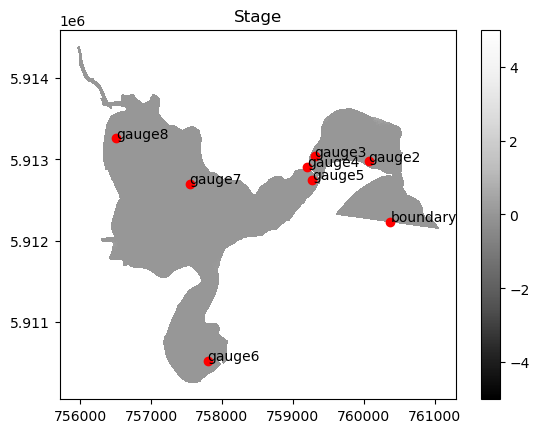

In [5]:
plt.tripcolor(splotter.triang,
              facecolors = splotter.stage[0,:],
              cmap='Greys_r',
              vmin= -5,
              vmax= 5.0
              )
plt.colorbar();
plt.title("Stage");
plt.scatter(gauge_x, gauge_y, color='red')
for i in range(8):
    plt.annotate(gauge_location['name'][i], [gauge_x[i], gauge_y[i]])

plt.show()


In [6]:
timesteps = splotter.stage.shape[0]
splotter.stage.shape

(3, 10785)

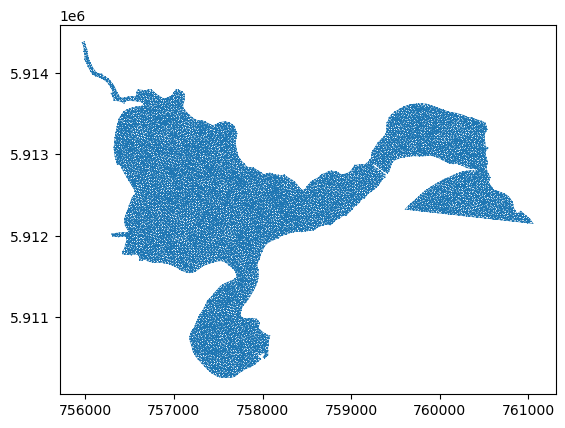

In [7]:
plt.triplot(splotter.triang, linewidth = 0.4);
plt.show()

In [8]:
import pprint
#pprint.pprint(gauge_ids)
for gid in gauge_ids:
    print(gid)
    #print(splotter.stage[:,gid])
    #plt.plot(splotter.stage[:,gid], label=gauge_location['name'][gid])

6408
6158
773
5
4585
6198
3136
3916


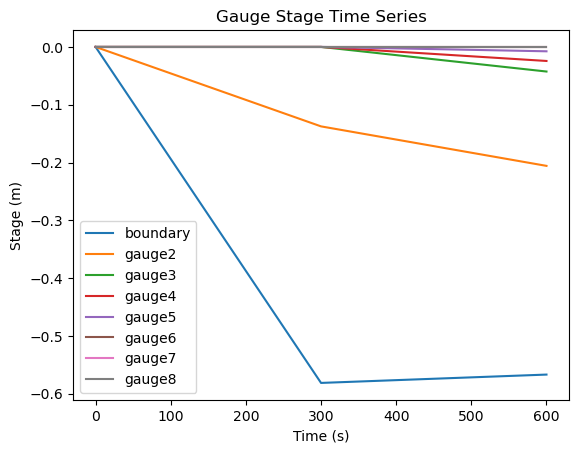

In [10]:
plt.plot(splotter.time, splotter.stage[:,gauge_ids])
plt.legend(gauge_location['name'])
plt.xlabel('Time (s)')
plt.ylabel('Stage (m)')
plt.title('Gauge Stage Time Series')
plt.show()

Gauge 4 measured stage data is missing gauge4


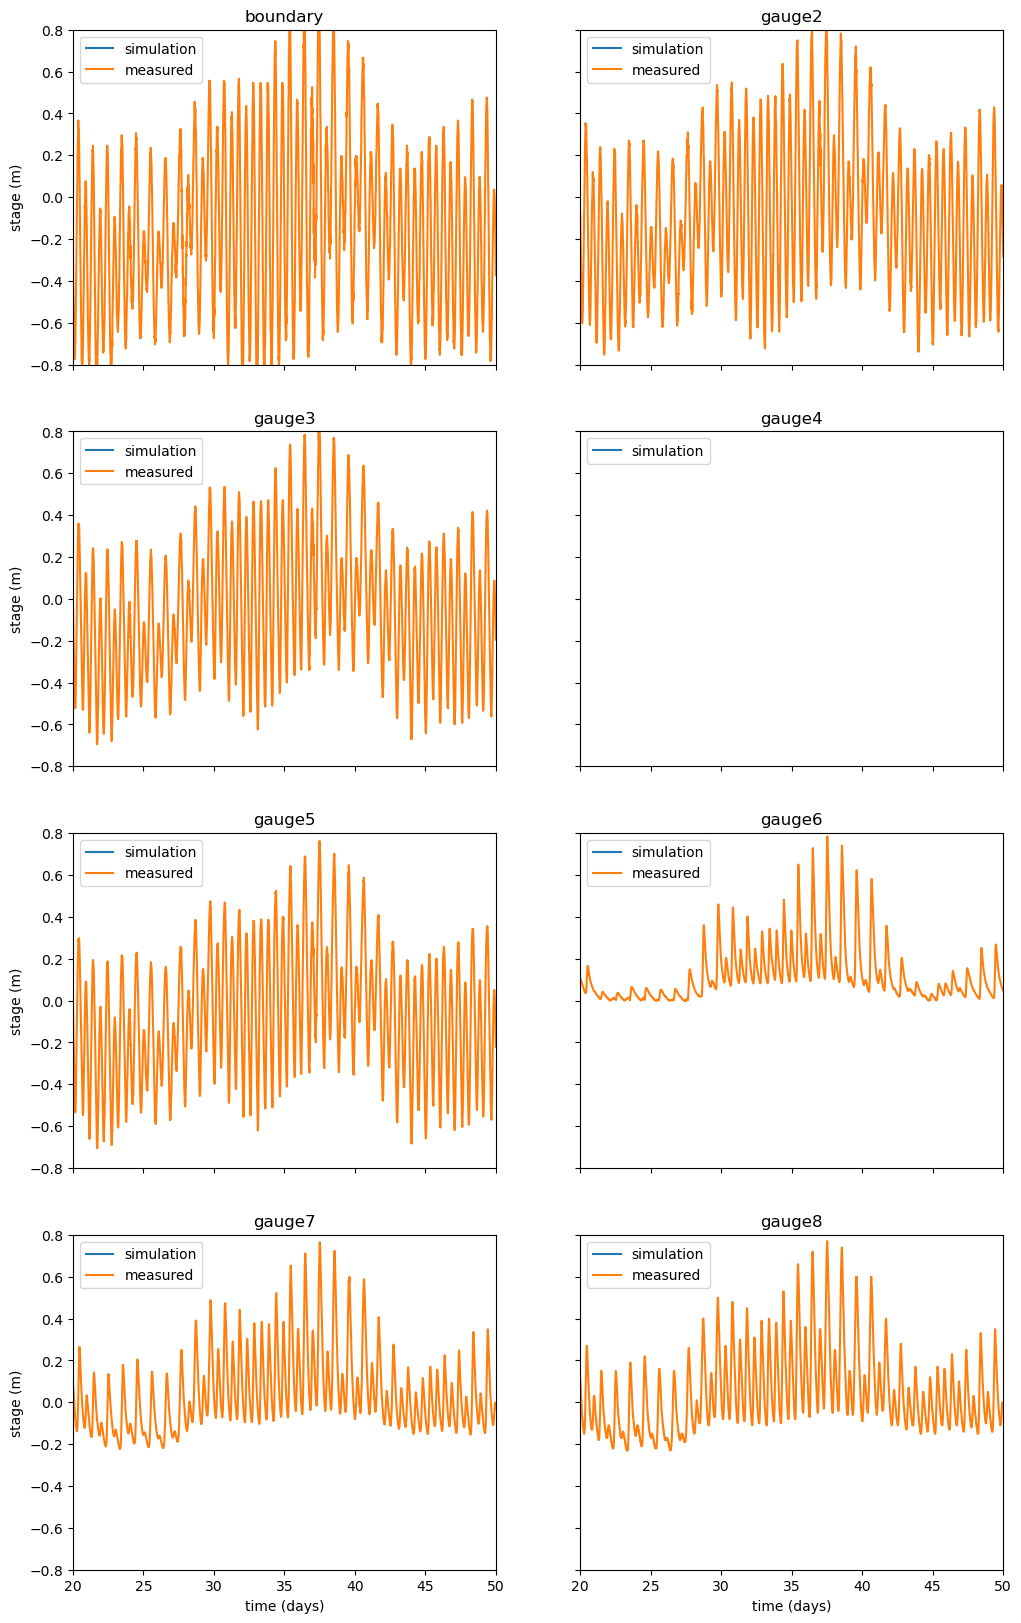

In [11]:
model_dir = '../../model_data_sept_2003'

sites = []

#for row in gauge_location.iterrows():

for index, row in gauge_location.iterrows():
    filename = anuga.join(model_dir,row['name']+'.txt')

    if row['name'] == 'gauge4':
        print(f"Gauge 4 measured stage data is missing {row['name']}")
        site = None
    else:
        site = pd.read_fwf(filename, header=None)
        site.columns = ['time', 'measured']
        site['time'] = site['time'] - 265

    sites.append(site)
        

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(12,20), sharex=True, sharey=True)

ax = ax1

for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]):

    ax.set_title(gauge_location['name'][i])
    ax.plot(splotter.time/3600/24, splotter.stage[:,gauge_ids[i]], label='simulation') 
    

    if gauge_location['name'][i] == 'gauge4':
        pass
    else:
        sites[i].plot('time','measured', ax=ax, label='measured')

    ax.legend(loc='upper left')
    ax.set_xlim(20.0, 50.0)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('time (days)')
    ax.set_ylabel('stage (m)')

plt.show()    


In [ ]:
for i in tqdm(range(0,timesteps,5)):
    splotter.save_speed_frame(figsize=(10, 8), vmax=2.0, vmin=0.0, frame=i)

splotter.make_speed_animation()

In [ ]:
for i in tqdm(range(0,timesteps,5)):
    splotter.save_stage_frame(figsize=(10, 8), vmax=2.0, vmin=-2.0, frame=i)

splotter.make_stage_animation()